## Generación del modelo

In [9]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# Cargar dataset final

processed_path = "/workspaces/tumipay_analysis/data/processed"
df_model = pd.read_csv(f"{processed_path}/model_input.csv")

In [11]:
# Definir variables
# -------------------------------
# Variable objetivo
y = df_model["riesgo_mora_30"]

# Variables predictoras
numeric_cols = ["edad", "ingreso_mensual_estimado", "score_externo",
                "monto_credito", "plazo_meses", "tasa_interes_mensual",
                "valor_cuota_pactada", "score_interno_originacion",
                "relacion_cuota_ingreso", "numero_dependientes",
                "total_eventos_pre", "duracion_promedio_pre"]

categorical_cols = ["genero", "estrato", "nivel_educativo",
                    "ocupacion", "producto_credito", "canal_originacion",
                    "politica_aprobacion", "estado_credito_operativo",
                    "dispositivo_principal"]

X = df_model[numeric_cols + categorical_cols]

In [12]:
# Preprocesamiento

# Escalado numéricas + OneHotEncoding categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),   # Imputar nulos con mediana
            ("scaler", StandardScaler())
        ]), numeric_cols),
        
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),  # Imputar nulos con "Desconocido"
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

In [13]:
# Definir modelo

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [14]:
# Train/Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [15]:
# Entrenar modelo

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['edad','ingreso_mensual_estimado','score_externo',..., 'politica_aprobacion','estado_credito_operativo','dispositivo_principal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default

Accuracy: 0.9934640522875817

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       334
           1       0.98      1.00      0.99       125

    accuracy                           0.99       459
   macro avg       0.99      1.00      0.99       459
weighted avg       0.99      0.99      0.99       459



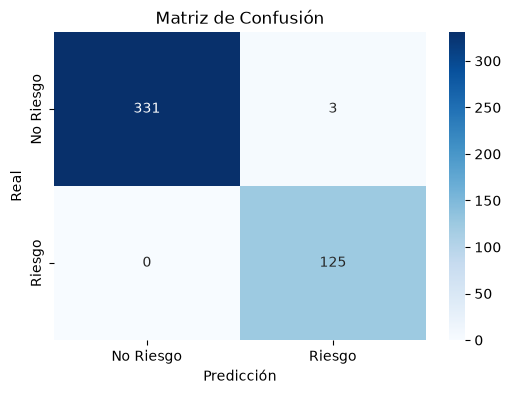

In [16]:
# Evaluación

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Riesgo", "Riesgo"],
            yticklabels=["No Riesgo", "Riesgo"])
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [21]:
# Exportar resultados

df_model["prob_riesgo"] = model.predict_proba(X)[:,1]
df_model.to_csv(f"{processed_path}/model_output.csv", index=False)

print("Resultados guardados en /data/processed/model_output.csv")

Resultados guardados en /data/processed/model_output.csv


                                   feature      coef  abs_coef
49    estado_credito_operativo_Mora severa  4.247591  4.247591
46         estado_credito_operativo_Activo -3.934810  3.934810
47     estado_credito_operativo_Finalizado -3.662000  3.662000
48  estado_credito_operativo_Mora moderada  3.342795  3.342795
45              politica_aprobacion_Manual -0.561022  0.561022
44           politica_aprobacion_Excepción  0.427608  0.427608
26                   ocupacion_Comerciante  0.406498  0.406498
11                   duracion_promedio_pre -0.358382  0.358382
41           canal_originacion_Call center  0.350758  0.350758
38           producto_credito_Microcrédito -0.319365  0.319365
6                      valor_cuota_pactada -0.299871  0.299871
34       producto_credito_Avance de nómina  0.298179  0.298179
14                       genero_No informa -0.269640  0.269640
23         nivel_educativo_Sin información  0.248630  0.248630
25           nivel_educativo_Universitario -0.248024  0

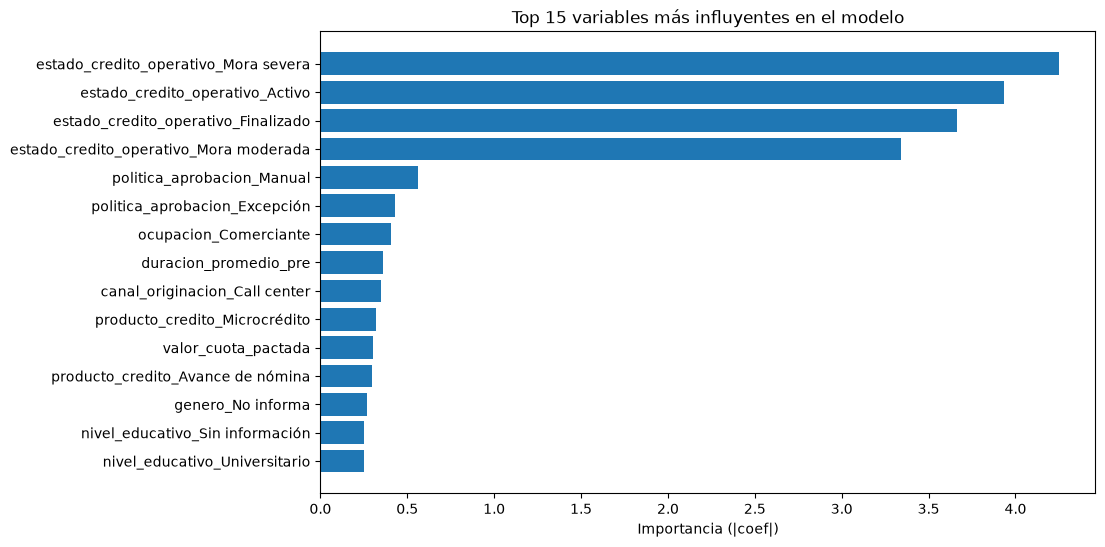

In [ ]:
# Análisis variables más importantes del modelo

numeric_features = numeric_cols

# Categóricas: se expanden con OneHotEncoder
categorical_features = list(
    model.named_steps["preprocessor"]
         .transformers_[1][1]   # pipeline de categóricas
         .named_steps["encoder"]
         .get_feature_names_out(categorical_cols)
)

# Concatenar todos los nombres de features
feature_names = numeric_features + categorical_features

# Extraer coeficientes del modelo
coefs = model.named_steps["classifier"].coef_[0]

# Crear DataFrame con importancia
importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
})

# Ordenar por magnitud absoluta
importance_sorted = importance.sort_values("abs_coef", ascending=False)

# Mostrar top 15 variables más influyentes
print(importance_sorted.head(15))

# Visualización rápida
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance_sorted["feature"].head(15),
         importance_sorted["abs_coef"].head(15))
plt.xlabel("Importancia (|coef|)")
plt.title("Top 15 variables más influyentes en el modelo")
plt.gca().invert_yaxis()
plt.show()
